In [28]:
import pandas as pd
import numpy as np
import os
import datetime
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pickle 

In [29]:
HWR_PATH = "RanSMAP/dataset/original/i3-gen12/ddr4-2133-16g" #"RanSMAP/dataset/original/i3-gen12/ddr4-3200-16g"

DATASET = "hiranomanabu/ransmap-2024-ransomware-behavioral-features"

strg_access_column_names = ['unix_time_s', 'unix_time_ns', 'lba', 'storage_size', 'storage_entropy']
mem_access_columns_names = ['unix_time_s', 'unix_time_ns', 'gpa', 'mem_size', 'mem_entropy', 'mem_access_type']

ransomware = set(["WannaCry", "Ryuk", "REvil", "LockBit", "Darkside", "Conti"])

ata_col_ind_to_name_map = dict(zip(range(len(strg_access_column_names)), strg_access_column_names))
mem_col_ind_to_name_map = dict(zip(range(len(mem_access_columns_names)), mem_access_columns_names))

kaggle_files_to_load = {
    'ata_read': ata_col_ind_to_name_map,
    'ata_write': ata_col_ind_to_name_map,
    'mem_read': mem_col_ind_to_name_map,
    'mem_write': mem_col_ind_to_name_map,
    'mem_readwrite': mem_col_ind_to_name_map,
    'mem_exec': mem_col_ind_to_name_map
}

NUMBER_OF_OPERATION_LOGS_TO_LOAD = 1

kagglehub.login()

## Get Operations_logs_to_load mapping

In [52]:
parent_folder_path = 'RanSMAP\\dataset\\original\\i3-gen12\\ddr4-2133-16g'
operation_names = os.listdir(parent_folder_path)
operation_paths = [os.path.join(parent_folder_path, operation) for operation in operation_names]

In [53]:
operations_logs_path = {}

for operation, operation_path in zip(operation_names, operation_paths):
    logs_path = [f"{operation}/{log_name}" for log_name in os.listdir(operation_path)]
    operations_logs_path[operation] = logs_path    

In [54]:
operations_logs_to_load = {}

if NUMBER_OF_OPERATION_LOGS_TO_LOAD == -1:
    operations_logs_to_load = operations_logs_path
else:
    for operation, logs in operations_logs_path.items():
        operations_logs_to_load[operation] = logs[:min(len(logs), NUMBER_OF_OPERATION_LOGS_TO_LOAD)]

In [55]:
operations_logs_to_load

{'AESCrypt': ['AESCrypt/AESCrypt-20230524_20-18-05'],
 'Conti': ['Conti/Conti-20230426_23-09-03'],
 'Darkside': ['Darkside/Darkside-20230512_00-06-29'],
 'Firefox': ['Firefox/Firefox-20230428_00-35-50'],
 'Idle': ['Idle/Idle-20230518_22-56-17'],
 'LockBit': ['LockBit/LockBit-20230517_21-35-46'],
 'Office': ['Office/Office-20230525_23-11-40'],
 'REvil': ['REvil/REvil-20230427_23-00-37'],
 'Ryuk': ['Ryuk/Ryuk-20230510_23-53-48'],
 'SDelete': ['SDelete/SDelete-20230519_00-20-40'],
 'WannaCry': ['WannaCry/WannaCry-20230510_21-11-33'],
 'Zip': ['Zip/Zip-20230524_22-57-19']}

## Import Local Dataset (ignore)

### Read Dataset and add relative timestamp

In [11]:
folder_path = "RanSMAP\\dataset\\original\\i3-gen12\\ddr4-2133-16g\\AESCrypt\\AESCrypt-20230524_20-18-05"

In [12]:
strg_read = pd.read_csv(os.path.join(folder_path, 'ata_read.csv'), names = strg_access_column_names, usecols=[i for i in range(5)])
strg_write = pd.read_csv(os.path.join(folder_path, 'ata_write.csv'), names = strg_access_column_names, usecols=[i for i in range(5)])
mem_read = pd.read_csv(os.path.join(folder_path, 'mem_read.csv'), names = mem_access_columns_names)
mem_write = pd.read_csv(os.path.join(folder_path, 'mem_write.csv'), names = mem_access_columns_names)
mem_read_write = pd.read_csv(os.path.join(folder_path, 'mem_readwrite.csv'), names = mem_access_columns_names)
mem_exec = pd.read_csv(os.path.join(folder_path, 'mem_exec.csv'), names = mem_access_columns_names)

strg_read['action'] = 'ata_read'
strg_write['action'] = 'ata_write'
mem_read['action'] = 'mem_read'
mem_write['action'] = 'mem_write'
mem_read_write['action'] = 'mem_read_write'
mem_exec['action'] = 'mem_exec'

In [13]:
mem_read.head()

,unix_time_s,unix_time_ns,gpa,mem_size,mem_entropy,mem_access_type,action
0,1684893977,194543354,7879543992,0,-1,2,mem_read
1,1684893977,194554089,66838552,0,-1,2,mem_read
2,1684893977,194564824,71733016,0,-1,2,mem_read
3,1684893977,194574485,70979088,0,-1,2,mem_read
4,1684893977,194585220,19186048,0,-1,2,mem_read


In [14]:
mem_write.head()

,unix_time_s,unix_time_ns,gpa,mem_size,mem_entropy,mem_access_type,action
0,1684893977,194817096,18618559496,4096,0.819862,2,mem_write
1,1684893977,198389704,4276093104,4096,0.170819,2,mem_write
2,1684893977,198910352,6470762232,4096,0.523777,2,mem_write
3,1684893977,199257092,6474102816,4096,0.701360,2,mem_write
4,1684893977,200457265,19204565860,4096,0.835809,2,mem_write


In [15]:
def get_datetime_min(time1, time2):
    time1_s, time1_ns = time1.unix_time_s, time1.unix_time_ns
    time2_s, time2_ns = time2.unix_time_s, time2.unix_time_ns
    
    if time1_s < time2_s:
        return time1
    elif time2_s < time1_s:
        return time2
    else:
        if time1_ns <= time2_ns:
            return time1
        return time2

In [16]:
start_point = get_datetime_min(
    get_datetime_min(
        get_datetime_min(
            get_datetime_min(
                get_datetime_min(strg_read.loc[0, ['unix_time_s', 'unix_time_ns']], strg_write.loc[0, ['unix_time_s', 'unix_time_ns']]), 
                mem_read.loc[0, ['unix_time_s', 'unix_time_ns']]), 
            mem_write.loc[0, ['unix_time_s', 'unix_time_ns']]), 
        mem_read_write.loc[0, ['unix_time_s', 'unix_time_ns']]), 
    mem_exec.loc[0, ['unix_time_s', 'unix_time_ns']])
start_point

unix_time_s     1684893977
unix_time_ns     194543354
Name: 0, dtype: object

In [17]:
start_point.unix_time_s, start_point.unix_time_ns

(np.int64(1684893977), np.int64(194543354))

In [18]:
def compute_relative_time(df, start_sec, start_nsec):
    """
    Compute relative time (in seconds and nanoseconds) from a start point.
    Keeps full nanosecond precision.
    """
    # Convert everything to total nanoseconds from the start point
    total_ns = (df['unix_time_s'] - start_sec) * 1_000_000_000 + (df['unix_time_ns'] - start_nsec)

    df['relative_time'] = pd.to_timedelta(total_ns, unit='ns')
    return df

In [19]:
# # start_sec, start_nsec = start_point.unix_time_s
# strg_read_new = compute_relative_time(strg_read, start_point.unix_time_s, start_point.unix_time_ns)
# strg_write_new = compute_relative_time(strg_write, start_point.unix_time_s, start_point.unix_time_ns)
# mem_read_new = compute_relative_time(mem_read, start_point.unix_time_s, start_point.unix_time_ns)
# mem_write_new = compute_relative_time(mem_write, start_point.unix_time_s, start_point.unix_time_ns)
# mem_read_write_new = compute_relative_time(mem_read_write, start_point.unix_time_s, start_point.unix_time_ns)
# mem_exec_new = compute_relative_time(mem_exec, start_point.unix_time_s, start_point.unix_time_ns)


strg_read = compute_relative_time(strg_read, start_point.unix_time_s, start_point.unix_time_ns)
strg_write = compute_relative_time(strg_write, start_point.unix_time_s, start_point.unix_time_ns)
mem_read = compute_relative_time(mem_read, start_point.unix_time_s, start_point.unix_time_ns)
mem_write = compute_relative_time(mem_write, start_point.unix_time_s, start_point.unix_time_ns)
mem_read_write = compute_relative_time(mem_read_write, start_point.unix_time_s, start_point.unix_time_ns)
mem_exec = compute_relative_time(mem_exec, start_point.unix_time_s, start_point.unix_time_ns)

In [20]:
strg_read.head()

,unix_time_s,unix_time_ns,lba,storage_size,storage_entropy,action,relative_time
0,1684893978,693442531,38952048,4096,-1,ata_read,0 days 00:00:01.498899177
1,1684893978,693442531,38952056,4096,-1,ata_read,0 days 00:00:01.498899177
2,1684893978,693443604,38952064,4096,-1,ata_read,0 days 00:00:01.498900250
3,1684893978,693443604,38952072,4096,-1,ata_read,0 days 00:00:01.498900250
4,1684893978,693444678,38952080,4096,-1,ata_read,0 days 00:00:01.498901324


### Save Files (Optional)

In [ ]:
# strg_read.to_csv(os.path.join(folder_path, 'modified', 'ata_read.csv'), index=False)
# strg_write.to_csv(os.path.join(folder_path, 'modified', 'ata_write.csv'), index=False)
# mem_read.to_csv(os.path.join(folder_path, 'modified', 'mem_read.csv'), index=False)
# mem_write.to_csv(os.path.join(folder_path, 'modified', 'mem_write.csv'), index=False)
# mem_read_write.to_csv(os.path.join(folder_path, 'modified', 'mem_readwrite.csv'), index=False)
# mem_exec.to_csv(os.path.join(folder_path, 'modified', 'mem_exec.csv'), index=False)

In [62]:
strg_read.head()

,unix_time_s,unix_time_ns,lba,storage_size,storage_entropy,relative_time
0,1684893978,693442531,38952048,4096,-1,0 days 00:00:01.498899177
1,1684893978,693442531,38952056,4096,-1,0 days 00:00:01.498899177
2,1684893978,693443604,38952064,4096,-1,0 days 00:00:01.498900250
3,1684893978,693443604,38952072,4096,-1,0 days 00:00:01.498900250
4,1684893978,693444678,38952080,4096,-1,0 days 00:00:01.498901324


In [74]:
strg_read_file_path = 'RanSMAP\\dataset\\original\\i3-gen12\\ddr4-2133-16g\\AESCrypt\\AESCrypt-20230524_20-18-05\\new\\ada_read.pkl'
with open(strg_read_file_path, 'wb') as file:
    pickle.dump(strg_read, file)
    
strg_write_file_path = 'RanSMAP\\dataset\\original\\i3-gen12\\ddr4-2133-16g\\AESCrypt\\AESCrypt-20230524_20-18-05\\new\\ada_write.pkl'
with open(strg_write_file_path, 'wb') as file:
    pickle.dump(strg_write, file)

mem_read_file_path = 'RanSMAP\\dataset\\original\\i3-gen12\\ddr4-2133-16g\\AESCrypt\\AESCrypt-20230524_20-18-05\\new\\mem_read.pkl'
with open(mem_read_file_path, 'wb') as file:
    pickle.dump(mem_read, file)
    
mem_write_file_path = 'RanSMAP\\dataset\\original\\i3-gen12\\ddr4-2133-16g\\AESCrypt\\AESCrypt-20230524_20-18-05\\new\\mem_write.pkl'
with open(mem_write_file_path, 'wb') as file:
    pickle.dump(mem_write, file)

mem_read_write_file_path = 'RanSMAP\\dataset\\original\\i3-gen12\\ddr4-2133-16g\\AESCrypt\\AESCrypt-20230524_20-18-05\\new\\mem_readwrite.pkl'
with open(mem_read_write_file_path, 'wb') as file:
    pickle.dump(mem_read_write, file)

mem_exec_file_path = 'RanSMAP\\dataset\\original\\i3-gen12\\ddr4-2133-16g\\AESCrypt\\AESCrypt-20230524_20-18-05\\new\\mem_exec.pkl'
with open(mem_exec_file_path, 'wb') as file:
    pickle.dump(mem_exec, file)

### Group Tables Together

In [21]:
combined_df = pd.concat([strg_read, strg_write, mem_read, mem_write, mem_read_write, mem_exec], ignore_index=True)
combined_df.drop(['unix_time_s', 'unix_time_ns'], axis=1, inplace=True)

## Generate Features

In [30]:
def timedelta_to_ns(t):
    if type(t) == pd.Timedelta:
        return t.total_seconds() * 1e9 + t.nanoseconds
    else:
        return t.total_seconds() * 1e9

In [31]:
# Temporal Evolution Features 
def temporal_evolution_features(strg_write_window_data, mem_write_window_data, mem_read_write_window_data, window_start, entropy_spike_threshold=0.9, consecutive_entropy_threshold=0.8):
    """
    Extract entropy transition features from raw event logs
    """
    
    def compute_acceleration(signal):
        """Compute 2nd derivative (acceleration)"""
        if len(signal) < 3:
            return 0 
        first_derivative = np.gradient(signal)
        second_derivative = np.gradient(first_derivative)
        return np.mean(second_derivative)

    def count_consecutive_above_threshold(values, threshold):
        """Find longest consecutive sequence above threshold"""
        above = (values > threshold).astype(int)
        max_consecutive = 0
        current = 0
        
        for val in above:
            if val == 1:
                current += 1
                max_consecutive = max(max_consecutive, current)
            else:
                current = 0
        
        return max_consecutive

    def compute_time_to_threshold(window_data, feature, window_start, threshold):
        """Time to first event above threshold in window"""
        high_entropy = window_data[window_data[feature] > threshold]
        if len(high_entropy) == 0:
            return np.nan
        return timedelta_to_ns(high_entropy['relative_time'].iloc[0] - window_start)
    
    def get_temporal_features_for_action(window_data, feature, window_start, entropy_spike_threshold, consecutive_entropy_threshold, prefix=''):
        features = {
            f'{prefix}_high_entropy_count': (window_data[feature] > entropy_spike_threshold).sum(),
            f'{prefix}_max_entropy_jump': np.diff(window_data[feature].values).max() if len(window_data) > 1 else 0,
            f'{prefix}_time_to_high_entropy': compute_time_to_threshold(window_data, feature, window_start, entropy_spike_threshold),
            
            # Sustained high entropy (consecutive events)
            f'{prefix}_sustained_high_entropy_events': count_consecutive_above_threshold(
                window_data[feature].values, threshold=consecutive_entropy_threshold
            ),
            f'{prefix}_storage_entropy_acceleration': compute_acceleration(window_data[feature].values),
        }
        return features
    
    features = {}
    
    features = features | get_temporal_features_for_action(strg_write_window_data[['relative_time', 'storage_entropy']], 'storage_entropy', window_start, 
                                                             entropy_spike_threshold, consecutive_entropy_threshold, 'storage_entropy')

    features = features | get_temporal_features_for_action(mem_write_window_data[['relative_time', 'mem_entropy']], 'mem_entropy', window_start, 
                                                             entropy_spike_threshold, consecutive_entropy_threshold, 'mem_write_entropy')
    
    features = features | get_temporal_features_for_action(mem_read_write_window_data[['relative_time', 'mem_entropy']], 'mem_entropy', window_start, 
                                                             entropy_spike_threshold, consecutive_entropy_threshold, 'mem_read_write_entropy')
    
    return features

# Burst Detection Features
def burst_features(strg_read_window_data, strg_write_window_data, mem_read_window_data, mem_write_window_data, mem_read_write_window_data, mem_exec_window_data, window_size_ns):
    """
    Detect bursts from raw event logs - critical for ransomware detection
    window_size_ns - size of window in nanoseconds
    """
    
    def compute_instant_throughput(df, timestamp_col='relative_time', size_col='size'):
        """
        - Groups rows with identical timestamps by summing sizes.
        - Computes throughput = grouped_size / (time difference to previous grouped timestamp) in seconds.
        - Broadcasts the grouped throughput back to the original rows so all rows with the same timestamp get the same throughput.
        Returns (df_with_throughput, grouped_df).
        """
        df2 = df.copy()
        if len(df2) < 1:
            df2['instant_throughput'] = []
            return df2
        
        # # Ensure sortable/time-aware timestamp column
        # if not (pd.api.types.is_datetime64_any_dtype(df2[timestamp_col]) or pd.api.types.is_timedelta64_dtype(df2[timestamp_col])):
        #     df2[timestamp_col] = pd.to_datetime(df2[timestamp_col])
        df2 = df2.sort_values(timestamp_col)
        
        start_time = df2.iloc[0][timestamp_col]
        if start_time == pd.Timedelta(0):
            start_time = pd.Timedelta(microseconds=0.001) # set start_time to 1ns

        # Group equal timestamps -> sum sizes
        grouped = df2.groupby(timestamp_col, sort=True)[size_col].sum().reset_index().rename(columns={size_col: 'size_sum'})

        # # Compute time difference to previous grouped timestamp (seconds)
        # if pd.api.types.is_timedelta64_dtype(grouped[timestamp_col]):
        #     grouped['time_diff_s'] = grouped[timestamp_col].dt.total_seconds().diff()
        # else:
        #     grouped[timestamp_col] = pd.to_datetime(grouped[timestamp_col])
        #     grouped['time_diff_s'] = grouped[timestamp_col].diff().dt.total_seconds()

        # diff is null only for first element which is the starting element
        grouped['time_diff_ns'] = grouped[timestamp_col].diff().apply(lambda x: timedelta_to_ns(start_time) if pd.isnull(x) else timedelta_to_ns(x))
        # Throughput: size / time_diff. First row will have NaN time_diff -> throughput NaN.
        grouped['throughput'] = grouped['size_sum'] / grouped['time_diff_ns']

        # Decide how to treat first row / zero diffs if desired (here left as NaN)
        # e.g. to set first throughput to 0: grouped['throughput'].fillna(0, inplace=True)

        # Map throughput back to original rows
        mapping = dict(zip(grouped[timestamp_col], grouped['throughput']))
        df2["instant_throughput"] = df2[timestamp_col].map(mapping)
        
        return df2
    
    def compute_burst_clustering(window_data, quantile_threshold = 0.75):
        """Measure temporal clustering of high-throughput events"""
        if len(window_data) < 2:
            return 0
        
        # Identify burst events (top (100-threshold)%)
        threshold = window_data['instant_throughput'].quantile(quantile_threshold)
        burst_times = window_data[window_data['instant_throughput'] > threshold]['relative_time'].values
        
        if len(burst_times) < 2:
            return 0
        
        # Compute average inter-burst interval
        inter_burst_intervals = np.diff(burst_times)
        
        # Lower values = more clustered
        return np.mean(inter_burst_intervals).astype(int) # numpy gives result in ns so no need to convert to ns.
    
    def get_burst_features_for_action(window_data, prefix, size_col, window_size_ns):
        window_data_w_throughput = compute_instant_throughput(window_data, size_col=size_col)
        features = {
            # Peak instantaneous throughput (would be averaged out in rolling features)
            f'{prefix}_peak_instant_throughput': window_data_w_throughput['instant_throughput'].max(),
                        
            # Throughput burst intensity (peak vs median)
            f'{prefix}_burst_intensity': (window_data_w_throughput['instant_throughput'].max() / (window_data_w_throughput['instant_throughput'].median() + 1e-10)),
            
            # Micro-burst count (events exceeding 2 std above mean)
            f'{prefix}_micro_burst_count': (window_data_w_throughput['instant_throughput'] > 
                                window_data_w_throughput['instant_throughput'].mean() + 2 * window_data_w_throughput['instant_throughput'].std()).sum(),
            
            # Burst clustering (how close are high-throughput events?)
            f'{prefix}_burst_clustering': compute_burst_clustering(window_data_w_throughput),
            
            # Event rate (events per second - lost in averaging)
            f'{prefix}_event_rate': len(window_data_w_throughput) / window_size_ns,
        }
        
        return features
    
    features = {}
    
    features = features | get_burst_features_for_action(strg_read_window_data, 'strg_read', 'storage_size', window_size_ns)
    features = features | get_burst_features_for_action(strg_write_window_data, 'strg_write', 'storage_size', window_size_ns)
    features = features | get_burst_features_for_action(mem_read_window_data, 'mem_read', 'mem_size', window_size_ns)
    features = features | get_burst_features_for_action(mem_write_window_data, 'mem_write', 'mem_size', window_size_ns)
    features = features | get_burst_features_for_action(mem_read_write_window_data, 'mem_read_write', 'mem_size', window_size_ns)
    features = features | get_burst_features_for_action(mem_exec_window_data, 'mem_exec', 'mem_size', window_size_ns)
    
    # strg_read_window_data_w_thrhpt = compute_instant_throughput(strg_read_window_data, )
    # strg_write_window_data_w_thrhpt = compute_instant_throughput(strg_write_window_data)
    
    # features = {
    #     # Peak instantaneous throughput (would be averaged out in rolling features)
    #     'strg_read_peak_instant_throughput': strg_read_window_data_w_thrhpt['instant_throughput'].max(),
    #     'strg_write_peak_instant_throughput': strg_write_window_data_w_thrhpt['instant_throughput'].max(),
        
    #     # Throughput burst intensity (peak vs median)
    #     'strg_read_burst_intensity': (strg_read_window_data_w_thrhpt['instant_throughput'].max() / (strg_read_window_data_w_thrhpt['instant_throughput'].median() + 1e-10)),
    #     'strg_write_burst_intensity': (strg_write_window_data_w_thrhpt['instant_throughput'].max() / (strg_write_window_data_w_thrhpt['instant_throughput'].median() + 1e-10)),
        
    #     # Micro-burst count (events exceeding 2 std above mean)
    #     'strg_read_micro_burst_count': (strg_read_window_data_w_thrhpt['instant_throughput'] > 
    #                         strg_read_window_data_w_thrhpt['instant_throughput'].mean() + 2 * strg_read_window_data_w_thrhpt['instant_throughput'].std()).sum(),
    #     'strg_write_micro_burst_count': (strg_write_window_data_w_thrhpt['instant_throughput'] > 
    #                         strg_write_window_data_w_thrhpt['instant_throughput'].mean() + 2 * strg_write_window_data_w_thrhpt['instant_throughput'].std()).sum(),
        
    #     # Burst clustering (how close are high-throughput events?)
    #     'strg_read_burst_clustering': compute_burst_clustering(strg_read_window_data_w_thrhpt),
    #     'strg_write_burst_clustering': compute_burst_clustering(strg_write_window_data_w_thrhpt),
        
    #     # Event rate (events per second - lost in averaging)
    #     'strg_read_event_rate': len(strg_read_window_data_w_thrhpt) / window_size_ns,
    #     'strg_write_event_rate': len(strg_write_window_data_w_thrhpt) / window_size_ns,
    # }
    
    return features

# Address Spatial Access Features
def spatial_access_patterns(strg_read_window_data, strg_write_window_data, mem_read_window_data, mem_write_window_data, mem_read_write_window_data, mem_exec_window_data):
    """
    Analyze LBA and GPA access sequences from raw events
    """
    
    def compute_sequential_ratio(addr_sequence):
        """Fraction of accesses that are sequential (LBA differs by 1)"""
        if len(addr_sequence) < 2:
            return 0
        
        diffs = np.abs(np.diff(addr_sequence))
        sequential = (diffs == 1).sum()
        return sequential / len(diffs)

    def compute_access_direction_ratio(addr_sequence):
        """Ratio of forward to backward accesses"""
        if len(addr_sequence) < 2:
            return 1.0
        
        diffs = np.diff(addr_sequence)
        forward = (diffs > 0).sum()
        backward = (diffs < 0).sum()
        
        return forward / (backward + 1e-10)

    def get_spatial_access_features_for_action(addr_sequence, prefix):
        # print("Processing spatial features for ", prefix)
        if prefix in ['strg_read', 'strg_write']:
            addr_name = 'lba'
        elif prefix in ['mem_read', 'mem_write', 'mem_read_write', 'mem_exec']:
            addr_name = 'gpa'
        else:
            addr_name = 'addr'
        features = { 
            # Sequential access ratio (consecutive LBAs)
            f'{prefix}_seq_addr_access_ratio': compute_sequential_ratio(addr_sequence),
            
            # LBA jump magnitude (average distance between accesses)
            f'{prefix}_avg_{addr_name}_jump': np.mean(np.abs(np.diff(addr_sequence))) if len(addr_sequence) > 1 else 0,
            f'{prefix}_max_{addr_name}_jump': np.max(np.abs(np.diff(addr_sequence))) if len(addr_sequence) > 1 else 0,
            
            # Access locality (number of unique LBAs vs total accesses)
            f'{prefix}_access_locality': len(np.unique(addr_sequence)) / len(addr_sequence) if len(addr_sequence) > 0 else 0,
            
            # Forward vs backward access ratio
            f'{prefix}_frwrd_bckwrd_ratio': compute_access_direction_ratio(addr_sequence),
            
            # LBA range covered
            f'{prefix}_{addr_name}_range': addr_sequence.max() - addr_sequence.min() if len(addr_sequence) > 0 else 0,
        }
        return features
    
    
    strg_read_addr_sequence = strg_read_window_data['lba'].values
    strg_write_addr_sequence = strg_write_window_data['lba'].values
    mem_read_addr_sequence = mem_read_window_data['gpa'].values
    mem_write_addr_sequence = mem_write_window_data['gpa'].values
    mem_read_write_addr_sequence = mem_read_write_window_data['gpa'].values
    mem_exec_addr_sequence = mem_exec_window_data['gpa'].values
    
    features = {}
    features = features | get_spatial_access_features_for_action(strg_read_addr_sequence, 'strg_read')
    features = features | get_spatial_access_features_for_action(strg_write_addr_sequence, 'strg_write')
    features = features | get_spatial_access_features_for_action(mem_read_addr_sequence, 'mem_read')
    features = features | get_spatial_access_features_for_action(mem_write_addr_sequence, 'mem_write')
    features = features | get_spatial_access_features_for_action(mem_read_write_addr_sequence, 'mem_read_write')
    features = features | get_spatial_access_features_for_action(mem_exec_addr_sequence, 'mem_exec')
        
    return features

In [ ]:
def ransmap_preprocessing(df: pd.DataFrame, is_ransomware: bool, operation: str, window_s: int, epsilon_s: int = 1) -> pd.DataFrame:
    '''
    window_s: Window size in seconds
    epsilon_s: Step size in seconds
    '''
    
    # preprocessed_df = pd.DataFrame(columns=["start", "end", 
    #                                         "avg_ata_read", "avg_ata_write", "lba_read_var", "lba_write_var", "avg_storage_entropy", 
    #                                         "avg_entropy_mem_write", "avg_entropy_mem_read_write", 
    #                                         "num_4KB_pages_mem_read", "num_4KB_pages_mem_write", "num_4KB_pages_mem_read_write", "num_4KB_pages_mem_exec",
    #                                         "num_2MB_pages_mem_read", "num_2MB_pages_mem_write", "num_2MB_pages_mem_read_write", "num_2MB_pages_mem_exec",
    #                                         "num_MIMO_pages_mem_read", "num_MIMO_pages_mem_write", "num_MIMO_pages_mem_read_write", "num_MIMO_pages_mem_exec",
    #                                         "gpa_mem_read_var", "gpa_mem_write_var", "gpa_mem_read_write_var", "gpa_mem_exec_var",
    #                                         ])
    
    
    data_rows = []
    window_delta = datetime.timedelta(seconds=window_s)
    epsilon_delta = datetime.timedelta(seconds=epsilon_s)
    
    last_start_possible = max(df['relative_time']) - window_delta
        
    start_time = min(df['relative_time']) # should be 0s
    
    strg_read = df[df['action'] == 'ata_read'][["relative_time", "lba", "storage_size"]]
    strg_write = df[df['action'] == 'ata_write'][["relative_time", "lba", "storage_size", "storage_entropy"]]
    mem_read = df[df['action'] == 'mem_read'][["relative_time", "gpa", 'mem_size', 'mem_entropy', 'mem_access_type']]
    mem_write = df[df['action'] == 'mem_write'][["relative_time", "gpa", 'mem_size', 'mem_entropy', 'mem_access_type']]
    mem_read_write = df[df['action'] == 'mem_read_write'][["relative_time", "gpa", 'mem_size', 'mem_entropy', 'mem_access_type']]
    mem_exec = df[df['action'] == 'mem_exec'][["relative_time", "gpa", 'mem_size', 'mem_entropy', 'mem_access_type']]
    
    while start_time <= last_start_possible:
        # print(f"Processing window from {start_time}")
        try:            
            end_time = start_time + window_delta

            # d_ata_read = df[(start_time <= df['relative_time']) & (df['relative_time'] <= end_time) & (df['action'] == 'ata_read')][["relative_time", "lba", "storage_size"]]
            # d_ata_write = df[(start_time <= df['relative_time']) & (df['relative_time'] <= end_time) & (df['action'] == 'ata_write')][["relative_time", "lba", "storage_size", "storage_entropy"]]
            # d_mem_read = df[(start_time <= df['relative_time']) & (df['relative_time'] <= end_time) & (df['action'] == 'mem_read')][["relative_time", "gpa", 'mem_size', 'mem_entropy', 'mem_access_type']]
            # d_mem_write = df[(start_time <= df['relative_time']) & (df['relative_time'] <= end_time) & (df['action'] == 'mem_write')][["relative_time", "gpa", 'mem_size', 'mem_entropy', 'mem_access_type']]
            # d_mem_read_write = df[(start_time <= df['relative_time']) & (df['relative_time'] <= end_time) & (df['action'] == 'mem_read_write')][["relative_time", "gpa", 'mem_size', 'mem_entropy', 'mem_access_type']]
            # d_mem_exec = df[(start_time <= df['relative_time']) & (df['relative_time'] <= end_time) & (df['action'] == 'mem_exec')][["relative_time", "gpa", 'mem_size', 'mem_entropy', 'mem_access_type']]
            
            d_ata_read = strg_read[(start_time <= strg_read['relative_time']) & (strg_read['relative_time'] <= end_time)]
            d_ata_write = strg_write[(start_time <= strg_write['relative_time']) & (strg_write['relative_time'] <= end_time)]
            d_mem_read = mem_read[(start_time <= mem_read['relative_time']) & (mem_read['relative_time'] <= end_time)]
            d_mem_write = mem_write[(start_time <= mem_write['relative_time']) & (mem_write['relative_time'] <= end_time)]
            d_mem_read_write = mem_read_write[(start_time <= mem_read_write['relative_time']) & (mem_read_write['relative_time'] <= end_time)]
            d_mem_exec = mem_exec[(start_time <= mem_exec['relative_time']) & (mem_exec['relative_time'] <= end_time)]
            # new = [start_time, end_time, 
            #        d_ata_read['storage_size'].sum() / window_s,
            #        d_ata_write['storage_size'].sum() / window_s,
            #        d_ata_read['lba'].var(),
            #        d_ata_write['lba'].var(),
            #        d_ata_write['storage_entropy'].mean(),
                
            #        d_mem_write['mem_entropy'].mean(), d_mem_read_write['mem_entropy'].mean(),
            #        len(d_mem_read[d_mem_read['mem_access_type'] == 1]), len(d_mem_write[d_mem_write['mem_access_type'] == 1]), len(d_mem_read_write[d_mem_read_write['mem_access_type'] == 1]), len(d_mem_exec[d_mem_exec['mem_access_type'] == 1]),
            #        len(d_mem_read[d_mem_read['mem_access_type'] == 2]), len(d_mem_write[d_mem_write['mem_access_type'] == 2]), len(d_mem_read_write[d_mem_read_write['mem_access_type'] == 2]), len(d_mem_exec[d_mem_exec['mem_access_type'] == 2]),
            #        len(d_mem_read[d_mem_read['mem_access_type'] == 4]), len(d_mem_write[d_mem_write['mem_access_type'] == 4]), len(d_mem_read_write[d_mem_read_write['mem_access_type'] == 4]), len(d_mem_exec[d_mem_exec['mem_access_type'] == 4]),
            #        d_mem_read['gpa'].var(), d_mem_write['gpa'].var(), d_mem_read_write['gpa'].var(), d_mem_exec['gpa'].var()
            #        ]
            
            features = {}
            
            features = features | {"start": start_time, "end": end_time}
            
            features = features | {
                "avg_ata_read": d_ata_read['storage_size'].sum() / window_s,
                "avg_ata_write": d_ata_write['storage_size'].sum() / window_s,
                "lba_read_var": d_ata_read['lba'].var(),
                "lba_write_var": d_ata_write['lba'].var(),
                "avg_storage_entropy": d_ata_write['storage_entropy'].mean()
            }
            
            features = features | {
                "avg_entropy_mem_write": d_mem_write['mem_entropy'].mean(),
                "avg_entropy_mem_read_write": d_mem_read_write['mem_entropy'].mean()
            }

            features = features | {
                "num_4KB_pages_mem_read": len(d_mem_read[d_mem_read['mem_access_type'] == 1]),
                "num_4KB_pages_mem_write": len(d_mem_write[d_mem_write['mem_access_type'] == 1]),
                "num_4KB_pages_mem_read_write": len(d_mem_read_write[d_mem_read_write['mem_access_type'] == 1]),
                "num_4KB_pages_mem_exec": len(d_mem_exec[d_mem_exec['mem_access_type'] == 1]),
                
                "num_2MB_pages_mem_read": len(d_mem_read[d_mem_read['mem_access_type'] == 2]),
                "num_2MB_pages_mem_write": len(d_mem_write[d_mem_write['mem_access_type'] == 2]),
                "num_2MB_pages_mem_read_write": len(d_mem_read_write[d_mem_read_write['mem_access_type'] == 2]),
                "num_2MB_pages_mem_exec": len(d_mem_exec[d_mem_exec['mem_access_type'] == 2]),
                
                "num_MMIO_pages_mem_read": len(d_mem_read[d_mem_read['mem_access_type'] == 4]),
                "num_MMIO_pages_mem_write": len(d_mem_write[d_mem_write['mem_access_type'] == 4]),
                "num_MMIO_pages_mem_read_write": len(d_mem_read_write[d_mem_read_write['mem_access_type'] == 4]),
                "num_MMIO_pages_mem_exec": len(d_mem_exec[d_mem_exec['mem_access_type'] == 4]),
            }
            
            features = features | {
                "gpa_mem_read_var": d_mem_read['gpa'].var(),
                "gpa_mem_write_var": d_mem_write['gpa'].var(),
                "gpa_mem_read_write_var": d_mem_read_write['gpa'].var(),
                "gpa_mem_exec_var": d_mem_exec['gpa'].var()
            }
            
            features = features | temporal_evolution_features(d_ata_write, d_mem_write, d_mem_read_write, start_time)
            features = features | burst_features(d_ata_read, d_ata_write, d_mem_read, d_mem_write, d_mem_read_write, d_mem_exec, window_s*1e9)
            features = features | spatial_access_patterns(d_ata_read, d_ata_write, d_mem_read, d_mem_write, d_mem_read_write, d_mem_exec)
        
        except:
            print("Error occurred at start time: ", start_time)
            return None
        # preprocessed_df.loc[len(preprocessed_df)] = new
        data_rows.append(features)
        
        start_time += epsilon_delta
    
    preprocessed_df = pd.DataFrame(data_rows)
    preprocessed_df['is_ransomware'] = is_ransomware
    preprocessed_df['operation'] = operation
    return preprocessed_df

In [37]:
new_process_df = ransmap_preprocessing(combined_df, False, 'AESCrypt', 30, 1)

Error occurred at start time:  0 days 00:01:17


##### tmp

In [34]:
new_process_df[new_process_df.columns[25:-2]].describe()

,storage_entropy_high_entropy_count,storage_entropy_max_entropy_jump,storage_entropy_time_to_high_entropy,storage_entropy_sustained_high_entropy_events,storage_entropy_storage_entropy_acceleration,mem_write_entropy_high_entropy_count,mem_write_entropy_max_entropy_jump,mem_write_entropy_time_to_high_entropy,mem_write_entropy_sustained_high_entropy_events,mem_write_entropy_storage_entropy_acceleration,...,mem_read_write_max_gpa_jump,mem_read_write_access_locality,mem_read_write_frwrd_bckwrd_ratio,mem_read_write_gpa_range,mem_exec_seq_addr_access_ratio,mem_exec_avg_gpa_jump,mem_exec_max_gpa_jump,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,mem_exec_gpa_range
count,171.000000,171.000000,1.710000e+02,171.000000,1.710000e+02,171.000000,171.000000,1.710000e+02,171.000000,1.710000e+02,...,1.710000e+02,171.000000,1.710000e+02,1.710000e+02,171.0,1.710000e+02,1.710000e+02,171.000000,171.000000,1.710000e+02
mean,68159.614035,0.987264,1.561433e+09,4004.128655,-5.098339e-06,546.245614,0.995189,1.484818e+09,6.719298,6.603598e-06,...,1.314783e+10,0.933896,5.263158e+08,1.382169e+10,0.0,2.461494e+08,9.928991e+08,0.578947,0.965135,1.127966e+09
std,30168.047985,0.042239,2.852148e+09,2180.398729,2.980654e-05,224.504784,0.000311,2.856779e+09,3.444114,2.875856e-05,...,2.032212e+09,0.037266,3.950154e+09,1.476913e+09,0.0,6.247962e+08,2.547081e+09,0.495178,0.185523,2.854732e+09
min,45.000000,0.766415,1.826080e+05,25.000000,-3.361119e-04,63.000000,0.994682,6.237600e+04,4.000000,-5.372108e-05,...,8.401909e+09,0.847458,9.545455e-01,1.064326e+10,0.0,0.000000e+00,0.000000e+00,0.000000,0.333333,0.000000e+00
25%,67114.000000,0.995046,2.347914e+08,2891.000000,-5.178284e-06,498.500000,0.995020,4.508236e+07,5.000000,-5.479473e-20,...,1.152131e+10,0.916317,1.427249e+00,1.318740e+10,0.0,0.000000e+00,0.000000e+00,0.000000,1.000000,0.000000e+00
50%,76581.000000,0.995346,6.510352e+08,3584.000000,-5.405523e-07,620.000000,0.995334,1.441569e+08,5.000000,1.359554e-20,...,1.365221e+10,0.927536,1.553191e+00,1.397931e+10,0.0,0.000000e+00,0.000000e+00,1.000000,1.000000,0.000000e+00
75%,91265.000000,0.995491,1.225457e+09,4052.000000,1.748944e-07,712.000000,0.995492,1.017684e+09,6.000000,2.174242e-05,...,1.496841e+10,0.954921,1.785714e+00,1.515836e+10,0.0,1.834883e+08,6.962277e+08,1.000000,1.000000,9.205726e+08
max,101689.000000,0.995571,1.575150e+10,7936.000000,4.963426e-05,849.000000,0.995574,1.390664e+10,14.000000,1.622423e-04,...,1.527068e+10,1.000000,3.000000e+10,1.812234e+10,0.0,5.425465e+09,1.951698e+10,1.000000,1.500000,1.956886e+10


In [21]:
tmp_start = pd.Timedelta(seconds=13, minutes=1)
tmp_end = tmp_start + datetime.timedelta(seconds=30)

tmp_ata_read = combined_df[(tmp_start <= combined_df['relative_time']) & (combined_df['relative_time'] <= tmp_end) & (combined_df['action'] == 'ata_read')][["relative_time", "lba", "storage_size"]]
tmp_ata_write = combined_df[(tmp_start <= combined_df['relative_time']) & (combined_df['relative_time'] <= tmp_end) & (combined_df['action'] == 'ata_write')][["relative_time", "lba", "storage_size", "storage_entropy"]]
tmp_mem_read = combined_df[(tmp_start <= combined_df['relative_time']) & (combined_df['relative_time'] <= tmp_end) & (combined_df['action'] == 'mem_read')][["relative_time", "gpa", 'mem_size', 'mem_entropy', 'mem_access_type']]
tmp_mem_write = combined_df[(tmp_start <= combined_df['relative_time']) & (combined_df['relative_time'] <= tmp_end) & (combined_df['action'] == 'mem_write')][["relative_time", "gpa", 'mem_size', 'mem_entropy', 'mem_access_type']]
tmp_mem_read_write = combined_df[(tmp_start <= combined_df['relative_time']) & (combined_df['relative_time'] <= tmp_end) & (combined_df['action'] == 'mem_read_write')][["relative_time", "gpa", 'mem_size', 'mem_entropy', 'mem_access_type']]
tmp_mem_exec = combined_df[(tmp_start <= combined_df['relative_time']) & (combined_df['relative_time'] <= tmp_end) & (combined_df['action'] == 'mem_exec')][["relative_time", "gpa", 'mem_size', 'mem_entropy', 'mem_access_type']]
        

In [24]:
tmp_burst_feat = burst_features(tmp_ata_read, tmp_ata_write, tmp_mem_read, tmp_mem_write, tmp_mem_read_write, tmp_mem_exec, 30*1e9)

In [25]:
tmp_burst_feat

{'strg_read_peak_instant_throughput': np.float64(73.8018018018018),
 'strg_read_burst_intensity': np.float64(9.675675675548824),
 'strg_read_micro_burst_count': np.int64(1545),
 'strg_read_burst_clustering': np.int64(11144177),
 'strg_read_event_rate': 3.1268e-06,
 'strg_write_peak_instant_throughput': np.float64(146.28571428571428),
 'strg_write_burst_intensity': np.float64(38.32142857042469),
 'strg_write_micro_burst_count': np.int64(181),
 'strg_write_burst_clustering': np.int64(2532250),
 'strg_write_event_rate': 2.7081e-06,
 'mem_read_peak_instant_throughput': np.float64(0.006950006108403806),
 'mem_read_burst_intensity': np.float64(69500061.08403805),
 'mem_read_micro_burst_count': np.int64(2),
 'mem_read_burst_clustering': np.int64(6974871654),
 'mem_read_event_rate': 1.0351e-06,
 'mem_write_peak_instant_throughput': np.float64(2.011787819253438),
 'mem_write_burst_intensity': np.float64(20117878192.534378),
 'mem_write_micro_burst_count': np.int64(23),
 'mem_write_burst_cluster

In [25]:
combined_df.head(2)

,lba,storage_size,storage_entropy,action,relative_time,gpa,mem_size,mem_entropy,mem_access_type
0,38952048.0,4096.0,-1.0,ata_read,0 days 00:00:01.498899177,NaN,NaN,NaN,NaN
1,38952056.0,4096.0,-1.0,ata_read,0 days 00:00:01.498899177,NaN,NaN,NaN,NaN


In [22]:
tmp_prep_df = ransmap_preprocessing(tmp_comb_new, False, 'AESCrypt', 30, 1)

In [196]:
tmp_prep_df

NameError: name 'tmp_prep_df' is not defined

In [27]:
strg_read_kaggle, strg_write_kaggle, mem_read_kaggle, mem_write_kaggle, mem_read_write_kaggle, mem_exec_kaggle = read_kaggle_access_file(HWR_PATH, DATASET, ['AESCrypt/AESCrypt-20230524_20-18-05'], kaggle_files_to_load)

In [29]:
strg_read_kaggle['action'] = 'ata_read'
strg_write_kaggle['action'] = 'ata_write'
mem_read_kaggle['action'] = 'mem_read'
mem_write_kaggle['action'] = 'mem_write'
mem_read_write_kaggle['action'] = 'mem_read_write'
mem_exec_kaggle['action'] = 'mem_exec'

start_point_kaggle = get_datetime_min(
    get_datetime_min(
        get_datetime_min(
            get_datetime_min(
                get_datetime_min(strg_read_kaggle.loc[0, ['unix_time_s', 'unix_time_ns']], strg_write_kaggle.loc[0, ['unix_time_s', 'unix_time_ns']]), 
                mem_read_kaggle.loc[0, ['unix_time_s', 'unix_time_ns']]), 
            mem_write_kaggle.loc[0, ['unix_time_s', 'unix_time_ns']]), 
        mem_read_write_kaggle.loc[0, ['unix_time_s', 'unix_time_ns']]), 
    mem_exec_kaggle.loc[0, ['unix_time_s', 'unix_time_ns']])
start_point_kaggle
# start_sec, start_nsec = start_point_kaggle.unix_time_s
strg_read_kaggle = compute_relative_time(strg_read_kaggle, start_point_kaggle.unix_time_s, start_point_kaggle.unix_time_ns)
strg_write_kaggle = compute_relative_time(strg_write_kaggle, start_point_kaggle.unix_time_s, start_point_kaggle.unix_time_ns)
mem_read_kaggle = compute_relative_time(mem_read_kaggle, start_point_kaggle.unix_time_s, start_point_kaggle.unix_time_ns)
mem_write_kaggle = compute_relative_time(mem_write_kaggle, start_point_kaggle.unix_time_s, start_point_kaggle.unix_time_ns)
mem_read_write_kaggle = compute_relative_time(mem_read_write_kaggle, start_point_kaggle.unix_time_s, start_point_kaggle.unix_time_ns)
mem_exec_kaggle = compute_relative_time(mem_exec_kaggle, start_point_kaggle.unix_time_s, start_point_kaggle.unix_time_ns)

In [40]:
tmp_comb_kaggle = pd.concat([strg_read_kaggle, strg_write_kaggle, mem_read_kaggle, mem_write_kaggle, mem_read_write_kaggle, mem_exec_kaggle], ignore_index=True)
tmp_comb_kaggle.drop(['unix_time_s', 'unix_time_ns'], axis=1, inplace=True)

tmp_prep_kaggle_df = ransmap_preprocessing(tmp_comb_kaggle, False, 'AESCrypt', 10, 1)

In [61]:
tmp_prep_kaggle_df.loc[tmp_prep_kaggle_df['gpa_mem_read_write_var'].isna(), ['start', 'end', 'gpa_mem_write_var', 'gpa_mem_read_write_var', 'gpa_mem_exec_var', 'num_2MB_pages_mem_write', 'num_2MB_pages_mem_read_write', 'num_2MB_pages_mem_exec']]

,start,end,gpa_mem_write_var,gpa_mem_read_write_var,gpa_mem_exec_var,num_2MB_pages_mem_write,num_2MB_pages_mem_read_write,num_2MB_pages_mem_exec
2,0 days 00:00:02,0 days 00:00:12,2.839607e+17,NaN,1.084051e+19,20,0,4
13,0 days 00:00:13,0 days 00:00:23,4.559068e+16,NaN,1.531475e+17,18,0,3
14,0 days 00:00:14,0 days 00:00:24,2.513320e+16,NaN,1.531475e+17,10,0,3
15,0 days 00:00:15,0 days 00:00:25,7.268173e+15,NaN,1.531475e+17,3,0,3
16,0 days 00:00:16,0 days 00:00:26,7.274909e+15,NaN,1.531475e+17,3,0,3
17,0 days 00:00:17,0 days 00:00:27,2.724874e+16,NaN,2.423665e+17,11,0,2
28,0 days 00:00:28,0 days 00:00:38,2.952971e+17,NaN,1.083861e+17,20,1,3
29,0 days 00:00:29,0 days 00:00:39,2.208700e+17,NaN,1.083861e+17,14,1,3
30,0 days 00:00:30,0 days 00:00:40,2.064565e+17,NaN,1.083861e+17,14,1,3
31,0 days 00:00:31,0 days 00:00:41,8.849231e+19,NaN,NaN,4,0,1


In [54]:
tmp_start = tmp_prep_kaggle_df.loc[tmp_prep_kaggle_df['gpa_mem_read_write_var'].isna(), ['start', 'end', 'gpa_mem_write_var', 'gpa_mem_read_write_var', 'gpa_mem_exec_var']].iloc[0]['start']
tmp_end = tmp_prep_kaggle_df.loc[tmp_prep_kaggle_df['gpa_mem_read_write_var'].isna(), ['start', 'end', 'gpa_mem_write_var', 'gpa_mem_read_write_var', 'gpa_mem_exec_var']].iloc[0]['end']
tmp_start, tmp_end

(Timedelta('0 days 00:00:02'), Timedelta('0 days 00:00:12'))

In [67]:
tmp_start, tmp_end = tmp_prep_kaggle_df.iloc[31].start, tmp_prep_kaggle_df.iloc[31].end
tmp_start, tmp_end

(Timedelta('0 days 00:00:31'), Timedelta('0 days 00:00:41'))

In [69]:
tmp_comb_kaggle[(tmp_start <= tmp_comb_kaggle['relative_time']) & (tmp_comb_kaggle['relative_time'] <= tmp_end) & (tmp_comb_kaggle['action'] <= 'mem_exec')]

,lba,storage_size,storage_entropy,action,relative_time,gpa,mem_size,mem_entropy,mem_access_type
17443,7929824.0,4096.0,-1.000000,ata_read,0 days 00:00:31.137278886,NaN,NaN,NaN,NaN
17444,7930096.0,4096.0,-1.000000,ata_read,0 days 00:00:31.139089881,NaN,NaN,NaN,NaN
17445,7930288.0,4096.0,-1.000000,ata_read,0 days 00:00:31.204678584,NaN,NaN,NaN,NaN
17446,66530784.0,4096.0,-1.000000,ata_read,0 days 00:00:31.205769260,NaN,NaN,NaN,NaN
17447,66530792.0,4096.0,-1.000000,ata_read,0 days 00:00:31.205770333,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
454961,30660272.0,4096.0,0.995686,ata_write,0 days 00:00:40.557817786,NaN,NaN,NaN,NaN
454962,30660280.0,4096.0,0.994538,ata_write,0 days 00:00:40.557817786,NaN,NaN,NaN,NaN
454963,30660288.0,4096.0,0.993541,ata_write,0 days 00:00:40.557818859,NaN,NaN,NaN,NaN
454964,30660296.0,4096.0,0.993782,ata_write,0 days 00:00:40.557818859,NaN,NaN,NaN,NaN


In [ ]:
tmp_comb_kaggle[(tmp_start <= tmp_comb_kaggle['relative_time']) & (tmp_comb_kaggle['relative_time'] <= tmp_end) & (tmp_comb_kaggle['action'] <= 'mem_exec')].isna().sum()

lba                   1
storage_size          1
storage_entropy       1
action                0
relative_time         0
gpa                5960
mem_size           5960
mem_entropy        5960
mem_access_type    5960
dtype: int64

: 

In [197]:
tmp_df = pd.read_pickle("processed_dataset/final_dataset_with_first_logs_window_10s.pkl")

In [200]:
tmp_df.iloc[55]['start']

Timedelta('0 days 00:00:55')

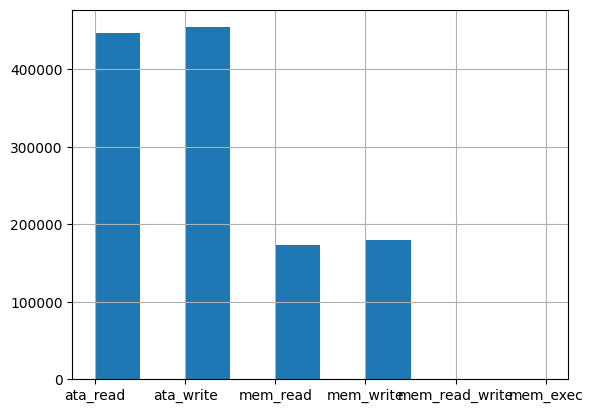

In [58]:
tmp_comb_kaggle['action'].hist();

In [59]:
tmp_df.columns

Index(['start', 'end', 'avg_ata_read', 'avg_ata_write', 'lba_read_var',
       'lba_write_var', 'avg_storage_entropy', 'avg_entropy_mem_write',
       'avg_entropy_mem_read_write', 'num_4KB_pages_mem_read',
       'num_4KB_pages_mem_write', 'num_4KB_pages_mem_read_write',
       'num_4KB_pages_mem_exec', 'num_2MB_pages_mem_read',
       'num_2MB_pages_mem_write', 'num_2MB_pages_mem_read_write',
       'num_2MB_pages_mem_exec', 'num_MIMO_pages_mem_read',
       'num_MIMO_pages_mem_write', 'num_MIMO_pages_mem_read_write',
       'num_MIMO_pages_mem_exec', 'gpa_mem_read_var', 'gpa_mem_write_var',
       'gpa_mem_read_write_var', 'gpa_mem_exec_var', 'is_ransomware',
       'operation', 'start_s', 'end_s'],
      dtype='object')

In [38]:
tmp_df[tmp_df['operation'] == 'AESCrypt'].tail()

,start,end,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,...,num_MIMO_pages_mem_read_write,num_MIMO_pages_mem_exec,gpa_mem_read_var,gpa_mem_write_var,gpa_mem_read_write_var,gpa_mem_exec_var,is_ransomware,operation,start_s,end_s
186,0 days 00:03:06,0 days 00:03:16,9955942.4,10043187.2,3.050936e+14,1.298645e+15,0.969269,0.026411,0.827855,0,...,0,0,2.607423e+18,2.936443e+18,1.468348e+18,NaN,False,AESCrypt,186,196
187,0 days 00:03:07,0 days 00:03:17,7258572.8,8775372.8,2.736349e+14,1.334559e+15,0.969026,0.026079,0.808333,0,...,0,0,2.804920e+18,3.037901e+18,1.647245e+18,NaN,False,AESCrypt,187,197
188,0 days 00:03:08,0 days 00:03:18,6163302.4,8798771.2,3.135492e+14,1.182254e+15,0.962432,0.025760,0.776282,0,...,0,0,3.175001e+18,3.141431e+18,2.032900e+18,NaN,False,AESCrypt,188,198
189,0 days 00:03:09,0 days 00:03:19,6084915.2,9985792.0,3.303985e+14,1.104112e+15,0.971500,0.024104,0.782497,0,...,0,0,2.761009e+18,2.939263e+18,2.318091e+18,NaN,False,AESCrypt,189,199
190,0 days 00:03:10,0 days 00:03:20,8433766.4,8809011.2,3.425340e+14,1.101733e+15,0.969972,0.025511,0.814015,0,...,0,0,2.789738e+18,3.003572e+18,1.959639e+18,NaN,False,AESCrypt,190,200


In [242]:
tmp_comb_new['mem_access_type'].unique()

array([nan,  2.,  1.,  4.])

In [ ]:
tmp_comb_new[(tmp_comb_new['action'] == 'mem_read_write') & (tmp_comb_new['mem_access_type'] == 4)]

,lba,storage_size,storage_entropy,action,relative_time,gpa,mem_size,mem_entropy,mem_access_type
901927,NaN,NaN,NaN,mem_read,0 days 00:00:00.317652944,1.887722e+09,0.0,-1.0,4.0
901928,NaN,NaN,NaN,mem_read,0 days 00:00:00.317677634,1.887699e+09,0.0,-1.0,4.0
901929,NaN,NaN,NaN,mem_read,0 days 00:00:00.317703398,1.887722e+09,0.0,-1.0,4.0
901930,NaN,NaN,NaN,mem_read,0 days 00:00:00.317777470,1.887722e+09,0.0,-1.0,4.0
901931,NaN,NaN,NaN,mem_read,0 days 00:00:00.317803234,1.887722e+09,0.0,-1.0,4.0
...,...,...,...,...,...,...,...,...,...
1074625,NaN,NaN,NaN,mem_read,0 days 00:03:20.258508057,1.889674e+09,0.0,-1.0,4.0
1074626,NaN,NaN,NaN,mem_read,0 days 00:03:20.258956780,1.889673e+09,0.0,-1.0,4.0
1074627,NaN,NaN,NaN,mem_read,0 days 00:03:20.258970735,1.889674e+09,0.0,-1.0,4.0
1074628,NaN,NaN,NaN,mem_read,0 days 00:03:20.258985764,1.889674e+09,0.0,-1.0,4.0


In [115]:
mem_read_new[mem_read_new['mem_access_type'] == 4]

,unix_time_s,unix_time_ns,gpa,mem_size,mem_entropy,mem_access_type,action,relative_time
365,1684893977,512196298,1887721504,0,-1,4,mem_read,0 days 00:00:00.317652944
366,1684893977,512220988,1887698952,0,-1,4,mem_read,0 days 00:00:00.317677634
367,1684893977,512246752,1887722320,0,-1,4,mem_read,0 days 00:00:00.317703398
368,1684893977,512320824,1887722320,0,-1,4,mem_read,0 days 00:00:00.317777470
369,1684893977,512346588,1887722320,0,-1,4,mem_read,0 days 00:00:00.317803234
...,...,...,...,...,...,...,...,...
173063,1684894177,453051411,1889674036,0,-1,4,mem_read,0 days 00:03:20.258508057
173064,1684894177,453500134,1889673224,0,-1,4,mem_read,0 days 00:03:20.258956780
173065,1684894177,453514089,1889674000,0,-1,4,mem_read,0 days 00:03:20.258970735
173066,1684894177,453529118,1889674040,0,-1,4,mem_read,0 days 00:03:20.258985764


In [117]:
mem_read_new[(mem_read_new['mem_access_type'] == 4) & (datetime.timedelta(seconds=1) <= mem_read_new['relative_time']) & (mem_read_new['relative_time'] <= datetime.timedelta(seconds=31))]

,unix_time_s,unix_time_ns,gpa,mem_size,mem_entropy,mem_access_type,action,relative_time
727,1684893978,528662428,1887721504,0,-1,4,mem_read,0 days 00:00:01.334119074
728,1684893978,528672089,1887698952,0,-1,4,mem_read,0 days 00:00:01.334128735
729,1684893978,528724691,1887722320,0,-1,4,mem_read,0 days 00:00:01.334181337
730,1684893978,528798762,1887722320,0,-1,4,mem_read,0 days 00:00:01.334255408
731,1684893978,528824526,1887722320,0,-1,4,mem_read,0 days 00:00:01.334281172
...,...,...,...,...,...,...,...,...
20684,1684894008,122334083,1889674040,0,-1,4,mem_read,0 days 00:00:30.927790729
20685,1684894008,122389905,1889674036,0,-1,4,mem_read,0 days 00:00:30.927846551
20686,1684894008,122597090,1889673224,0,-1,4,mem_read,0 days 00:00:30.928053736
20687,1684894008,122609972,1889674000,0,-1,4,mem_read,0 days 00:00:30.928066618


In [278]:
tmp_prep_df[[col for col in tmp_prep_df.columns.to_list() if 'MIMO' in col]].max()

num_MIMO_pages_mem_read          36268
num_MIMO_pages_mem_write         37667
num_MIMO_pages_mem_read_write        0
num_MIMO_pages_mem_exec              0
dtype: int64

In [243]:
tmp_comb[(tmp_prep_df.loc[0, 'start'] <= tmp_comb['relative_time']) & (tmp_comb['relative_time'] <= tmp_prep_df.loc[0, 'end']) & (tmp_comb['action'] == 'ata_read')][['relative_time', 'storage_size']]

,relative_time,storage_size
0,0 days 00:00:01.498899177,4096.0
1,0 days 00:00:01.498899177,4096.0
2,0 days 00:00:01.498900250,4096.0
3,0 days 00:00:01.498900250,4096.0
4,0 days 00:00:01.498901324,4096.0
...,...,...
16326,0 days 00:00:28.092173423,4096.0
16327,0 days 00:00:28.092174496,4096.0
16328,0 days 00:00:28.092174496,4096.0
16329,0 days 00:00:28.092175570,4096.0


# Dataset Generation

In [118]:
# def get_combined_timestamp(row):
#     return pd.to_datetime(datetime.datetime.fromtimestamp(row['unix_time_s']).strftime("%Y-%m-%dT%H:%M:%S") + "." + str(row['unix_time_ns']))

def get_datetime_min(time1, time2):
    time1_s, time1_ns = time1.unix_time_s, time1.unix_time_ns
    time2_s, time2_ns = time2.unix_time_s, time2.unix_time_ns
    
    if time1_s < time2_s:
        return time1
    elif time2_s < time1_s:
        return time2
    else:
        if time1_ns <= time2_ns:
            return time1
        return time2

def compute_relative_time(df, start_sec, start_nsec):
    """
    Compute relative time (in seconds and nanoseconds) from a start point.
    Keeps full nanosecond precision.
    """
    # Convert everything to total nanoseconds from the start point
    total_ns = (df['unix_time_s'] - start_sec) * 1_000_000_000 + (df['unix_time_ns'] - start_nsec)

    df['relative_time'] = pd.to_timedelta(total_ns, unit='ns')
    return df

In [ ]:
# def read_access_file(operation_path):
#     folder_paths = [os.path.join(operation_path, os.listdir(operation_path)[0])]
#     strg_read = pd.DataFrame(columns = strg_access_column_names)
#     strg_write = pd.DataFrame(columns = strg_access_column_names)
#     mem_read = pd.DataFrame(columns = mem_access_columns_names)
#     mem_write = pd.DataFrame(columns = mem_access_columns_names)
#     mem_read_write = pd.DataFrame(columns = mem_access_columns_names)
#     mem_exec = pd.DataFrame(columns = mem_access_columns_names)
    
#     for folder_path in folder_paths:
#         strg_read = pd.concat([strg_read, pd.read_csv(os.path.join(folder_path, 'ata_read.csv'), names = strg_access_column_names, usecols=[i for i in range(5)])])
#         strg_write = pd.concat([strg_write, pd.read_csv(os.path.join(folder_path, 'ata_write.csv'), names = strg_access_column_names, usecols=[i for i in range(5)])])
#         mem_read = pd.concat([mem_read, pd.read_csv(os.path.join(folder_path, 'mem_read.csv'), names = mem_access_columns_names)])
#         mem_write = pd.concat([mem_write, pd.read_csv(os.path.join(folder_path, 'mem_write.csv'), names = mem_access_columns_names)])
#         mem_read_write = pd.concat([mem_read_write, pd.read_csv(os.path.join(folder_path, 'mem_readwrite.csv'), names = mem_access_columns_names)])
#         mem_exec = pd.concat([mem_exec, pd.read_csv(os.path.join(folder_path, 'mem_exec.csv'), names = mem_access_columns_names)])
    
#     return strg_read, strg_write, mem_read, mem_write, mem_read_write, mem_exec

In [10]:
kaggle_files_to_load

{'ata_read': {0: 'unix_time_s',
  1: 'unix_time_ns',
  2: 'lba',
  3: 'storage_size',
  4: 'storage_entropy'},
 'ata_write': {0: 'unix_time_s',
  1: 'unix_time_ns',
  2: 'lba',
  3: 'storage_size',
  4: 'storage_entropy'},
 'mem_read': {0: 'unix_time_s',
  1: 'unix_time_ns',
  2: 'gpa',
  3: 'mem_size',
  4: 'mem_entropy',
  5: 'mem_access_type'},
 'mem_write': {0: 'unix_time_s',
  1: 'unix_time_ns',
  2: 'gpa',
  3: 'mem_size',
  4: 'mem_entropy',
  5: 'mem_access_type'},
 'mem_readwrite': {0: 'unix_time_s',
  1: 'unix_time_ns',
  2: 'gpa',
  3: 'mem_size',
  4: 'mem_entropy',
  5: 'mem_access_type'},
 'mem_exec': {0: 'unix_time_s',
  1: 'unix_time_ns',
  2: 'gpa',
  3: 'mem_size',
  4: 'mem_entropy',
  5: 'mem_access_type'}}

In [39]:
def read_kaggle_access_file(HWR_PATH, DATASET, operations_logs, kaggle_files_to_load):
    strg_read = None #pd.DataFrame(columns = strg_access_column_names)
    strg_write = None #pd.DataFrame(columns = strg_access_column_names)
    mem_read = None #pd.DataFrame(columns = mem_access_columns_names)
    mem_write = None #pd.DataFrame(columns = mem_access_columns_names)
    mem_read_write = None #pd.DataFrame(columns = mem_access_columns_names)
    mem_exec = None #pd.DataFrame(columns = mem_access_columns_names)
    
            
    for file, columns in kaggle_files_to_load.items():
        comb_df = pd.DataFrame()
        for log in operations_logs:
            file_path = f"{HWR_PATH}/{log}/{file}.csv"
            new_df = kagglehub.dataset_load(
                KaggleDatasetAdapter.PANDAS,
                DATASET,
                file_path,
                pandas_kwargs={"names": columns.values(), "usecols": columns.keys()}
                )
            
            comb_df = pd.concat([comb_df, new_df], ignore_index=True)
            
        match file:
            case 'ata_read':
                # strg_read = pd.concat([strg_read, new_df], ignore_index=True)
                strg_read = comb_df
            case 'ata_write':
                # strg_write = pd.concat([strg_write, new_df], ignore_index=True)
                strg_write = comb_df
            case 'mem_read':
                # mem_read = pd.concat([mem_read, new_df], ignore_index=True)
                mem_read = comb_df
            case 'mem_write':
                # mem_write = pd.concat([mem_write, new_df], ignore_index=True)
                mem_write = comb_df
            case 'mem_readwrite':
                # mem_read_write = pd.concat([mem_read_write, new_df], ignore_index=True)
                mem_read_write = comb_df
            case 'mem_exec':
                # mem_exec = pd.concat([mem_exec, new_df], ignore_index=True)
                mem_exec = comb_df
                        
    
    return strg_read, strg_write, mem_read, mem_write, mem_read_write, mem_exec

In [38]:
def generate_combined_log_file(strg_read, strg_write, mem_read, mem_write, mem_read_write, mem_exec):
    
    # strg_read, strg_write, mem_read, mem_write, mem_read_write, mem_exec = read_access_file(operation_path)
    
    strg_read['action'] = 'ata_read'
    strg_write['action'] = 'ata_write'
    mem_read['action'] = 'mem_read'
    mem_write['action'] = 'mem_write'
    mem_read_write['action'] = 'mem_read_write'
    mem_exec['action'] = 'mem_exec'
    
    start_point = get_datetime_min(
                    get_datetime_min(
                        get_datetime_min(
                            get_datetime_min(
                                get_datetime_min(strg_read.loc[0, ['unix_time_s', 'unix_time_ns']], strg_write.loc[0, ['unix_time_s', 'unix_time_ns']]), 
                                mem_read.loc[0, ['unix_time_s', 'unix_time_ns']]), 
                            mem_write.loc[0, ['unix_time_s', 'unix_time_ns']]), 
                        mem_read_write.loc[0, ['unix_time_s', 'unix_time_ns']]), 
                    mem_exec.loc[0, ['unix_time_s', 'unix_time_ns']])

    # start_point_datetime = get_combined_timestamp(start_point)
    
    # strg_read['timestamp'] = strg_read[['unix_time_s', 'unix_time_ns']].apply(lambda x: get_combined_timestamp(x), axis=1)
    # strg_write['timestamp'] = strg_write[['unix_time_s', 'unix_time_ns']].apply(lambda x: get_combined_timestamp(x), axis=1)
    # mem_read['timestamp'] = mem_read[['unix_time_s', 'unix_time_ns']].apply(lambda x: get_combined_timestamp(x), axis=1)
    # mem_write['timestamp'] = mem_write[['unix_time_s', 'unix_time_ns']].apply(lambda x: get_combined_timestamp(x), axis=1)
    # mem_read_write['timestamp'] = mem_read_write[['unix_time_s', 'unix_time_ns']].apply(lambda x: get_combined_timestamp(x), axis=1)
    # mem_exec['timestamp'] = mem_exec[['unix_time_s', 'unix_time_ns']].apply(lambda x: get_combined_timestamp(x), axis=1)
    
    # strg_read['relative_time'] = strg_read['timestamp'].apply(lambda x: x - start_point_datetime)
    # strg_write['relative_time'] = strg_write['timestamp'].apply(lambda x: x - start_point_datetime)
    # mem_read['relative_time'] = mem_read[['timestamp']].apply(lambda x: x - start_point_datetime)
    # mem_write['relative_time'] = mem_write[['timestamp']].apply(lambda x: x - start_point_datetime)
    # mem_read_write['relative_time'] = mem_read_write[['timestamp']].apply(lambda x: x - start_point_datetime)
    # mem_exec['relative_time'] = mem_exec[['timestamp']].apply(lambda x: x - start_point_datetime)
    
    # start_sec, start_nsec = start_point.unix_time_s
    strg_read = compute_relative_time(strg_read, start_point.unix_time_s, start_point.unix_time_ns)
    strg_write = compute_relative_time(strg_write, start_point.unix_time_s, start_point.unix_time_ns)
    mem_read = compute_relative_time(mem_read, start_point.unix_time_s, start_point.unix_time_ns)
    mem_write = compute_relative_time(mem_write, start_point.unix_time_s, start_point.unix_time_ns)
    mem_read_write = compute_relative_time(mem_read_write, start_point.unix_time_s, start_point.unix_time_ns)
    mem_exec = compute_relative_time(mem_exec, start_point.unix_time_s, start_point.unix_time_ns)

    # strg_comb = pd.concat([strg_read, strg_write], ignore_index=True)
    # strg_comb.drop(['unix_time_s', 'unix_time_ns'], axis=1, inplace=True)
    
    # mem_comb = pd.concat([mem_read, mem_write, mem_read_write, mem_exec], ignore_index=True)
    # mem_comb.drop(['unix_time_s', 'unix_time_ns'], axis=1, inplace=True)
    
    # combined_logs = pd.concat([strg_comb, mem_comb], ignore_index=True)
    
    combined_logs = pd.concat([strg_read, strg_write, mem_read, mem_write, mem_read_write, mem_exec], ignore_index=True)
    combined_logs.drop(['unix_time_s', 'unix_time_ns'], axis=1, inplace=True)
    
    return combined_logs

In [ ]:
interim_path = 'interm_df'

In [47]:
tmp_strg = pd.read_pickle(interim_file_path)

In [50]:
def generate_dataset(HWR_PATH, DATASET, operations_logs_to_load, kaggle_files_to_load, window_s: int, epsilon_s: int, ransomware):
    final_dataset = pd.DataFrame()
    for operation, operation_logs in operations_logs_to_load.items():
        for operation_log_cnt, log in enumerate(operation_logs):
            
            print(f"Reading {operation} log {operation_log_cnt+1} ({log}) from Kaggle")
            strg_read, strg_write, mem_read, mem_write, mem_read_write, mem_exec = read_kaggle_access_file(HWR_PATH, DATASET, [log], kaggle_files_to_load)
            print(f"Combining {operation} log {operation_log_cnt+1} files")
            combined_log_files = generate_combined_log_file(strg_read, strg_write, mem_read, mem_write, mem_read_write, mem_exec)
            print(f"Creating features using {operation} log {operation_log_cnt+1} files")
            feature_dataset = ransmap_preprocessing(combined_log_files, operation in ransomware, operation, window_s, epsilon_s)
            print(f"Finished Creating feature dataset for {operation} log {operation_log_cnt+1}\n")
            feature_dataset['operation_log_cnt'] = operation_log_cnt+1
            
            interim_file_path = os.path.join(interim_path, f"{operation}_{operation_log_cnt+1}.pkl")
            with open(interim_file_path, 'wb') as file:
                pickle.dump(feature_dataset, file)
            
            final_dataset = pd.concat([final_dataset, feature_dataset], ignore_index=True)
    
    final_dataset['start_s'] = final_dataset['start'].apply(lambda x: x.seconds)
    final_dataset['end_s'] = final_dataset['end'].apply(lambda x: x.seconds)
    return final_dataset

In [56]:
operations_logs_path

{'AESCrypt': ['AESCrypt/AESCrypt-20230524_20-18-05',
  'AESCrypt/AESCrypt-20230524_20-25-28',
  'AESCrypt/AESCrypt-20230524_20-32-05',
  'AESCrypt/AESCrypt-20230524_20-40-05',
  'AESCrypt/AESCrypt-20230524_20-46-41',
  'AESCrypt/AESCrypt-20230524_20-53-12',
  'AESCrypt/AESCrypt-20230524_20-59-49',
  'AESCrypt/AESCrypt-20230524_21-07-05',
  'AESCrypt/AESCrypt-20230524_21-13-49',
  'AESCrypt/AESCrypt-20230524_21-22-51'],
 'Conti': ['Conti/Conti-20230426_23-09-03',
  'Conti/Conti-20230426_23-17-20',
  'Conti/Conti-20230426_23-24-52',
  'Conti/Conti-20230426_23-32-08',
  'Conti/Conti-20230426_23-47-25',
  'Conti/Conti-20230426_23-55-33',
  'Conti/Conti-20230427_00-03-10',
  'Conti/Conti-20230427_22-36-03',
  'Conti/Conti-20230427_22-43-56',
  'Conti/Conti-20230427_22-51-09'],
 'Darkside': ['Darkside/Darkside-20230512_00-06-29',
  'Darkside/Darkside-20230517_20-19-04',
  'Darkside/Darkside-20230517_20-26-40',
  'Darkside/Darkside-20230517_20-35-37',
  'Darkside/Darkside-20230517_20-44-25',


In [19]:
operations_logs_to_load

{'AESCrypt': ['AESCrypt/AESCrypt-20230524_20-18-05'],
 'Conti': ['Conti/Conti-20230426_23-09-03'],
 'Darkside': ['Darkside/Darkside-20230512_00-06-29'],
 'Firefox': ['Firefox/Firefox-20230428_00-35-50'],
 'Idle': ['Idle/Idle-20230518_22-56-17'],
 'LockBit': ['LockBit/LockBit-20230517_21-35-46'],
 'Office': ['Office/Office-20230525_23-11-40'],
 'REvil': ['REvil/REvil-20230427_23-00-37'],
 'Ryuk': ['Ryuk/Ryuk-20230510_23-53-48'],
 'SDelete': ['SDelete/SDelete-20230519_00-20-40'],
 'WannaCry': ['WannaCry/WannaCry-20230510_21-11-33'],
 'Zip': ['Zip/Zip-20230524_22-57-19']}

In [125]:
final_dataset = generate_dataset(HWR_PATH, DATASET, operations_logs_to_load, kaggle_files_to_load, 30, 1, ransomware)

Reading AESCrypt logs from Kaggle
Combining AESCrypt log files
Creating features using AESCrypt log files
Finished Creating feature dataset for AESCrypt

Reading Conti logs from Kaggle
Combining Conti log files
Creating features using Conti log files
Finished Creating feature dataset for Conti

Reading Darkside logs from Kaggle


100%|██████████| 5.26M/5.26M [00:00<00:00, 9.88MB/s]


100%|██████████| 16.4M/16.4M [00:01<00:00, 14.0MB/s]


100%|██████████| 17.3M/17.3M [00:01<00:00, 15.5MB/s]


100%|██████████| 18.9M/18.9M [00:01<00:00, 16.7MB/s]


...

100%|██████████| 6.43M/6.43M [00:00<00:00, 11.9MB/s]


100%|██████████| 19.6k/19.6k [00:00<00:00, 1.01MB/s]


100%|██████████| 7.65k/7.65k [00:00<00:00, 3.91MB/s]

Combining Zip log files
Creating features using Zip log files


Finished Creating feature dataset for Zip



In [57]:
final_dataset_10s_wind = generate_dataset(HWR_PATH, DATASET, operations_logs_path, kaggle_files_to_load, 10, 1, ransomware)

Reading AESCrypt log 1 (AESCrypt/AESCrypt-20230524_20-18-05) from Kaggle
Combining AESCrypt log 1 files
Creating features using AESCrypt log 1 files
Finished Creating feature dataset for AESCrypt log 1

Reading AESCrypt log 2 (AESCrypt/AESCrypt-20230524_20-25-28) from Kaggle
Combining AESCrypt log 2 files
Creating features using AESCrypt log 2 files
Finished Creating feature dataset for AESCrypt log 2

Reading AESCrypt log 3 (AESCrypt/AESCrypt-20230524_20-32-05) from Kaggle
Combining AESCrypt log 3 files
Creating features using AESCrypt log 3 files
Finished Creating feature dataset for AESCrypt log 3

Reading AESCrypt log 4 (AESCrypt/AESCrypt-20230524_20-40-05) from Kaggle
Combining AESCrypt log 4 files
Creating features using AESCrypt log 4 files
Finished Creating feature dataset for AESCrypt log 4

Reading AESCrypt log 5 (AESCrypt/AESCrypt-20230524_20-46-41) from Kaggle
Combining AESCrypt log 5 files
Creating features using AESCrypt log 5 files
Finished Creating feature dataset for A

In [58]:
final_dataset_10s_wind.head()

,start,end,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,...,mem_exec_avg_gpa_jump,mem_exec_max_gpa_jump,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,mem_exec_gpa_range,is_ransomware,operation,operation_log_cnt,start_s,end_s
0,0 days 00:00:00,0 days 00:00:10,420300.8,78233.6,8.750598e+14,2.836417e+15,0.742203,0.049471,0.753775,9,...,5.529372e+09,1.951698e+10,1.0,0.959677,1.956886e+10,False,AESCrypt,1,0,10
1,0 days 00:00:01,0 days 00:00:11,420300.8,78233.6,8.750598e+14,2.836417e+15,0.742203,0.011468,0.595073,1,...,4.865936e+09,1.218004e+10,1.0,0.909091,1.937828e+10,False,AESCrypt,1,1,11
2,0 days 00:00:02,0 days 00:00:12,1121177.6,79052.8,4.981796e+14,2.843206e+15,0.740121,0.004692,NaN,0,...,2.166676e+09,7.452113e+09,1.0,0.333333,7.554102e+09,False,AESCrypt,1,2,12
3,0 days 00:00:03,0 days 00:00:13,1362073.6,6144.0,5.017219e+14,4.499802e+14,0.399652,0.008459,0.637976,0,...,2.758968e+09,7.482259e+09,1.0,1.000000,7.887104e+09,False,AESCrypt,1,3,13
4,0 days 00:00:04,0 days 00:00:14,1407027.2,4505.6,4.985177e+14,2.045721e+13,0.362840,0.008541,0.637976,0,...,2.758968e+09,7.482259e+09,1.0,1.000000,7.887104e+09,False,AESCrypt,1,4,14


In [66]:
final_dataset_10s_wind = final_dataset_10s_wind.rename(columns={'num_MIMO_pages_mem_read': 'num_MMIO_pages_mem_read', 
                                                                'num_MIMO_pages_mem_write': 'num_MMIO_pages_mem_write',
                                                                'num_MIMO_pages_mem_read_write': 'num_MMIO_pages_mem_read_write',
                                                                'num_MIMO_pages_mem_exec': 'num_MMIO_pages_mem_exec'})


In [67]:
with open(os.path.join("processed_dataset", "final_dataset_new_features_all_logs_10s_window.pkl"), "wb") as file:
    pickle.dump(final_dataset_10s_wind, file)
    

In [75]:
final_dataset_10s_wind[final_dataset_10s_wind.columns[25:-5]].describe()

,storage_entropy_high_entropy_count,storage_entropy_max_entropy_jump,storage_entropy_time_to_high_entropy,storage_entropy_sustained_high_entropy_events,storage_entropy_storage_entropy_acceleration,mem_write_entropy_high_entropy_count,mem_write_entropy_max_entropy_jump,mem_write_entropy_time_to_high_entropy,mem_write_entropy_sustained_high_entropy_events,mem_write_entropy_storage_entropy_acceleration,...,mem_read_write_max_gpa_jump,mem_read_write_access_locality,mem_read_write_frwrd_bckwrd_ratio,mem_read_write_gpa_range,mem_exec_seq_addr_access_ratio,mem_exec_avg_gpa_jump,mem_exec_max_gpa_jump,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,mem_exec_gpa_range
count,23319.000000,23319.000000,2.187300e+04,23319.000000,2.331900e+04,23319.000000,23319.000000,1.716500e+04,23319.000000,2.331900e+04,...,2.331900e+04,23319.000000,2.331900e+04,2.331900e+04,23319.0,2.331900e+04,2.331900e+04,23319.000000,2.331900e+04,2.331900e+04
mean,11370.824564,0.914121,1.177956e+09,1024.688409,-1.911425e-04,43.616922,0.841652,1.604563e+09,2.330374,2.493338e-05,...,3.732627e+09,0.658197,1.665595e+09,3.852790e+09,0.0,2.915591e+08,6.812296e+08,0.309539,5.990823e+08,7.196608e+08
std,16673.829749,0.157841,1.727988e+09,1582.124680,5.301793e-03,66.214025,0.319522,2.305961e+09,1.995586,3.134925e-04,...,5.924022e+09,0.453906,6.430760e+09,6.114733e+09,0.0,1.278237e+09,2.773374e+09,0.455156,3.201035e+09,2.940859e+09
min,0.000000,-0.022179,1.070000e+02,0.000000,-3.592018e-01,0.000000,0.000000,2.633000e+03,0.000000,-1.250051e-02,...,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00
25%,36.000000,0.918605,1.549400e+08,15.000000,-3.288770e-05,0.000000,0.870698,1.039315e+08,1.000000,-2.401816e-21,...,0.000000e+00,0.000000,1.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000,1.000000e+00,0.000000e+00
50%,4093.000000,0.994401,5.859051e+08,256.000000,-8.553445e-07,10.000000,0.993972,4.726540e+08,2.000000,2.815253e-21,...,3.773646e+07,1.000000,1.000000e+00,4.215675e+07,0.0,0.000000e+00,0.000000e+00,0.000000,1.000000e+00,0.000000e+00
75%,16556.500000,0.995183,1.289249e+09,1599.500000,7.191833e-06,63.000000,0.994742,2.148556e+09,3.000000,2.935638e-05,...,1.111726e+10,1.000000,2.000000e+00,1.129822e+10,0.0,0.000000e+00,0.000000e+00,1.000000,1.000000e+00,0.000000e+00
max,123284.000000,0.996122,9.998127e+09,12800.000000,8.070633e-02,593.000000,0.998868,9.995211e+09,21.000000,1.497029e-02,...,1.957337e+10,1.000000,9.000000e+10,1.958295e+10,0.0,1.905140e+10,1.958005e+10,1.000000,9.000000e+10,1.958554e+10
